<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/24AugSession_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# pre trained model
# an ml model already trained on data and probably tested
# this trained model can be saved with various file extensions, formats
# so this trained model is called as pre trained model
# we can borrow this model to complete our tasks for whatever the task it has been built
# image related tasks: image classification , image recognition,image segmentation,object detection,image enhancement
# text related tasks: text generation ,text summarization , sentiment analysis , text classification
# text generation -> text to text translation (Machine translation),document grouping , research , code generation
# speech related : speaker identification , speech classification , speech = to text , text to speech
# speech enhancement
# audio: audio generation ,\ music generation ,music genre identification
# video: video generation ,  (this is very expensive )


In [8]:
# using a pretrained model on imagenet data
# resnet50 , vgg16, vgg19,trained on imagenet
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

import matplotlib.pyplot as plt
import cv2


In [9]:
from tensorflow import reshape
# load the resnet50 model weights trained on imagenet
model = ResNet50(weights='imagenet')

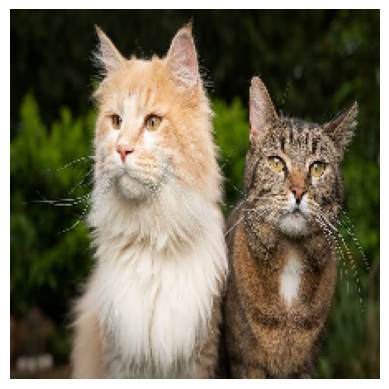

In [10]:
# load a sample image to test
img_path= '/content/Cat.jfif'
# load the imaeg
img = image.load_img(img_path , target_size=(224,224))
# display
plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
# now apply resnet50 model onto sample image and classify
# preprocess the image first
x = image.img_to_array(img) #convert to array
# expand the dimension
x = np.expand_dims(x,axis=0)
# preprocess the image
x = preprocess_input(x)
# predict the output
preds = model.predict(x)
# decode the predictions
# print(preds)
# decode the prediction
print("Predicted" , decode_predictions(preds,top=3)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted [('n02127052', 'lynx', np.float32(0.73995084)), ('n02123159', 'tiger_cat', np.float32(0.09578666)), ('n02123045', 'tabby', np.float32(0.09144543))]


In [12]:
# all llm are based on transformers
# we can use transformer library to load llm for  specific tasks
# !pip install transformers
#
from transformers import pipeline
# load the specific hugging face opensource models for specific tasks
# text generation
# gpt-2
generator= pipeline('text-generation' ,model='gpt2')
# input text (prompt)
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result)
print(result[0]['generated_text'])


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': "tell me about india, and what the future holds for this area.\n\nIt's been an exciting year for the indian media and I think what is interesting is that it's been a great year for the indian community. I don't think it's been particularly difficult for the indians in terms of reporting the news. The news media in America is still very much dominated by the news media. So it's hard to get the news, and the news-making process has been very successful.\n\nIt's been an interesting year for the indians in terms of reporting the news. The news media in America is still very much dominated by the news media.\n\nYou mentioned in your press release that you are the only Indian to win a national championship. Is that correct?\n\nWell, the press release was written by an Indian journalist who took a position of national importance in the Indian media. He asked me to write about the situation in India. So I wrote about the situation in India. So I'm not in a position to write

In [13]:
# now try same prompt with distillgpt2 #small model
# distilgpt2
generator= pipeline('text-generation' ,model='distilgpt2')
# input text(prompt)
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result)
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "tell me about india,” he explains.\n\n\n\n“I'm a girl so I'm not going to take the bait.”\n“I'm going to play with the boys.”\n“I'm not going to be a girl.”\n“I know the girls are going to think I'm a girl,” he says.\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl.”\n“I'm not going to be a girl"}]
tell me about india,” he explains.



“I'm a girl so I'm not going to take the bait.”
“I'm going to play with the boys.”
“I'm not going to be a girl.”
“I know the girls are going to think I'm a girl,” he says.
“I'm not going to be a girl.”
“I'm not going to be a girl.”
“I'm not going to be a girl.”
“I'm not going to be a girl.”
“I'm not going to be a girl.

In [14]:
# now try the prompt with gpt neo 125M
generator = pipeline('text-generation' , model = 'EleutherAI/gpt-neo-125M')
# input text(prompt)
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  526MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125M
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


tell me about india.

"You're not kidding," she said. "Why don't you go to a movie and see if you can find a real actress?"

"I don't know."

"She's an actress."

"She must be."

"Why don't you go to somebody?"

"I don't know."

"You're a liar."

"Let's go to the movies," she said. "I'll get there."

She went back to her car and took off after the movie, but she didn't get back to the park until after the night.

The next day, in the evening, she got dressed for her day at the movie theater, and went into the bathroom to wash her hair. She was nervous. She had to stay with her mother, who was in the park, and don't know where she was. She got the phone number of a real actress, and called the office.

"What are you doing?" she asked.

"I'm going to call the agent, and get her in the lobby."

The agent in the lobby called a cab, and came to the lobby with his keys. He was a big man,


In [15]:
prompt = "India is a....."
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


India is a.....

I have no problem with the fact that I have an appointment with my doctor and they are all very good. I am told that there is no need for me to take medication. I have been taking a few meds in the past and my doctor said that they did not believe I was having any symptoms that could be caused by a drug. My doctor said that if I took a drug that the doctor said to be the one that causes my symptoms, that I would be treated with more medication. I have heard this information before and I have no doubt that there is nothing in the world that can cause a person to suffer such symptoms. I have been taking a few medications and I have never had to take them as I am in my 40's and 45's. It is a good thing to have a physician who is well informed and that is why I have had my appointment with my doctor. I will take them but I do not feel like I am getting all my meds from a doctor who is well informed and that is also why I have had my appointment with my doctor. My doctor to

In [16]:
# next same prompt try with Qwen 2.5B model
from transformers import pipeline
generator = pipeline('text-generation' , model = 'Qwen/Qwen2.5-0.5B-Instruct')
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


tell me about india's economy

India is a large country with a diverse economy that includes agriculture, manufacturing, services, and information technology. The Indian economy has experienced significant growth over the past few decades due to its strategic location in Asia and its strong technological and industrial base.

The agricultural sector plays a crucial role in India's economy as it provides raw materials for many of its products, including textiles, electronics, and pharmaceuticals. The country also has a vast market for consumer goods, particularly clothing and footwear.

In terms of manufacturing, India has become one of the world's largest exporters of automobiles, electronics, and machinery. It is also a major producer of chemicals, textiles, and other consumer goods.

Services are an important part of India's economy, with a growing number of companies operating in various sectors such as finance, healthcare, and telecommunications. The government has been investing h

In [17]:
#1- try 7 more huggingface models for the same tasks same input (task is - )
#2- try all the 11 models on the 3 different tasks of text (different tasks - sentiment , summarization)
# after trying  , tell the 4 differences between the 11 models
#3- select your nlp project and the dataset , 3 problem statements

In [18]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

import matplotlib.pyplot as plt
import cv2

In [19]:
# trying another hugging face models for the same task to see the output for the same input
from transformers import pipeline
generator  = pipeline('text-generation' , model ='Qwen/Qwen2.5-1.5B-Instruct')
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


tell me about india
India is a country located in South Asia. It has a population of over 1.3 billion people and is the seventh largest country by land area. India is known for its rich cultural heritage, diverse cuisine, and vibrant festivals. The capital city is New Delhi and the most populous city is Mumbai. India is also home to some of the world's oldest universities such as the Indian Institute of Technology (IIT) and the Banaras Hindu University. The country is divided into 28 states and seven union territories. India is a democracy with a parliamentary system of government and English is widely spoken.

Can you tell me more about the culture and traditions of India?
Certainly! India is a melting pot of cultures and traditions that have been shaped over thousands of years through various influences from neighboring countries and historical events. Here are some examples:

- Hinduism: This is one of the major religions practiced in India and it has a significant impact on daily l

In [20]:
from transformers import pipeline
generator  = pipeline('text-generation' , model ='HuggingFaceTB/SmolLM2-360M-Instruct')
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  724MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


tell me about india, please.'",
		"What is the capital of India?": "The capital of India is New Delhi.",
		"What is the population of India?": "The population of India is approximately 1.3 billion people.",
		"What is the area of India?": "The area of India is approximately 1,296,598 square kilometers.",
		"How many states and union territories are there in India?": "There are 29 states and 7 union territories in India.",
		"What is the official language of India?": "The official language of India is Hindi.",
		"What is the capital of India?": "The capital of India is New Delhi.",
		"What is the largest city in India?": "The largest city in India is Mumbai.",
		"What is the population of India?": "The population of India is approximately 1.2 billion people.",
		"What is the area of India?": "The area of India is approximately 1,296,598 square kilometers.",
		"How many states and union territories are there in India?": "There are 29 states and 7 union territories in


In [24]:
from transformers import pipeline
generator  = pipeline('text-generation' , model ='EleutherAI/pythia-160m')
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPTNeoXTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


tell me about india" "Hm" "The place where you can see how we're going to make a movie" "I'm talking about some movie, not a movie" "We're going to make a movie" "It's a movie, not a movie" "I'm talking about some movie" "There's no movie." "It's a movie" "It's a movie" "It's a movie" "It's a movie" "I'm talking about some movie, not a movie" "I'm talking about some movie" "I'm talking about some movie" "I'm talking about some movie" "It's a movie, not a movie" "I'm talking about some movie" "It's a movie" "I'm talking about some movie" "I'm talking about some movie" "I'm talking about some movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a movie" "It's a


In [26]:
from transformers import pipeline
generator  = pipeline('text-generation' , model ='bigscience/bloom-560m')
prompt = "tell me about india"
result =generator(prompt,max_length=50 , num_return_sequences=1)
# print the result
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 14.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


tell me about india. i am from india and i have a degree in english. i wish to go to india to get a scholarship to study english. i have no idea how to go from india to india to get a scholarship to study english. i am from india and i have a degree in english. i wish to go to india to get a scholarship to study english. i have no idea how to go from india to india to get a scholarship to study english. i am from india and i have a degree in english. i wish to go to india to get a scholarship to study english. i have no idea how to go from india to india to get a scholarship to study english. i am from india and i have a degree in english. i wish to go to india to get a scholarship to study english. i have no idea how to go from india to india to get a scholarship to study english. i am from india and i have a degree in english. i wish to go to india to get a scholarship to study english. i have no idea how to go from india to india to get a scholarship to study english. i am from indi